# 🧠 **Clustering con DBSCAN: teoría, comparación con K-Means e implementación en Python**

Este notebook hace parte de un módulo introductorio-intermedio de un Diplomado en Ciencia de Datos. El objetivo es estudiar el algoritmo **DBSCAN** desde una perspectiva conceptual y práctica. A lo largo del material revisaremos su intuición geométrica, sus diferencias frente a **K-Means**, y dos formas de implementación: una usando una librería estándar de Machine Learning y otra construida desde cero para comprender la lógica interna del algoritmo.

### 🔜 **Introducción**

En problemas de aprendizaje no supervisado, una tarea fundamental consiste en encontrar grupos o estructuras latentes en los datos. Sin embargo, no todos los algoritmos de clustering funcionan bien cuando los grupos tienen formas irregulares, existen observaciones atípicas o no se conoce previamente cuántos clusters deben existir. En este contexto, **DBSCAN** aparece como una alternativa poderosa basada en densidad.

##### 🎯 **Objetivos de la sesión**

- Comprender la intuición matemática y geométrica detrás de DBSCAN.
- Identificar los conceptos de vecindad, puntos núcleo, puntos frontera y ruido.
- Comparar DBSCAN con K-Means en términos de supuestos, ventajas y limitaciones.
- Implementar DBSCAN usando `scikit-learn`.
- Implementar una versión de DBSCAN desde cero usando NumPy para entender la mecánica interna del algoritmo.

##### 🧭 **¿Qué veremos?**

Primero construiremos la idea de clustering por densidad y presentaremos los parámetros clave de DBSCAN: `eps` y `min_samples`. Luego contrastaremos este enfoque con K-Means. Finalmente, trabajaremos sobre un conjunto de datos sintético con estructura no lineal, resolveremos el clustering con una librería y después reproduciremos la lógica del algoritmo manualmente.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### 🌌 **¿Qué es DBSCAN?**

**DBSCAN** significa *Density-Based Spatial Clustering of Applications with Noise*. La idea central es que un cluster puede entenderse como una región del espacio donde los puntos están suficientemente concentrados. En lugar de buscar centros o particionar todo el conjunto de datos, DBSCAN expande regiones densas y separa puntos aislados como ruido.

##### 🧩 **Intuición del algoritmo**

DBSCAN comienza revisando, para cada observación, cuántos vecinos tiene en un radio `eps`. Si un punto tiene al menos `min_samples` vecinos dentro de esa vecindad, se considera un **punto núcleo**. A partir de un punto núcleo, el algoritmo expande el cluster incorporando puntos que estén conectados por densidad. Los puntos que no alcanzan densidad suficiente, pero quedan cerca de puntos núcleo, pueden actuar como **puntos frontera**. Los puntos que no pertenecen a ninguna región densa son etiquetados como **ruido**.

##### 📌 **Conceptos fundamentales**

- **Vecindad ε (`eps`)**: radio alrededor de un punto.
- **`min_samples`**: número mínimo de puntos requeridos en la vecindad para considerar un punto como núcleo.
- **Punto núcleo**: tiene densidad suficiente en su vecindad.
- **Punto frontera**: no tiene densidad suficiente por sí solo, pero está cerca de un punto núcleo.
- **Ruido**: punto que no puede asignarse a ningún cluster denso.

##### ⚙️ **Parámetros clave**

La calidad del resultado depende mucho de la elección de `eps` y `min_samples`. Si `eps` es muy pequeño, muchos puntos quedarán como ruido. Si es demasiado grande, clusters distintos pueden fusionarse. Por su parte, `min_samples` controla qué tan estricta es la noción de densidad. En términos prácticos, elegir estos parámetros requiere combinar intuición geométrica, escala de los datos y experimentación.

##### 🧮 **Idea algorítmica resumida**

A nivel procedimental, DBSCAN sigue una lógica parecida a la siguiente:
1. Revisar un punto no visitado.
2. Encontrar sus vecinos dentro del radio `eps`.
3. Si no alcanza `min_samples`, marcarlo temporalmente como ruido.
4. Si sí alcanza `min_samples`, iniciar un nuevo cluster.
5. Expandir el cluster agregando vecinos de puntos núcleo conectados por densidad.
6. Repetir hasta procesar todos los puntos.

### ⚖️ **DBSCAN vs K-Means**

Aunque ambos algoritmos se usan para clustering, sus supuestos son muy diferentes. K-Means busca particiones alrededor de centroides y suele funcionar mejor cuando los grupos son aproximadamente convexos o esféricos. DBSCAN, en cambio, busca regiones densas y puede capturar estructuras mucho más flexibles.

##### 🔍 **Diferencias conceptuales**

- **K-Means** requiere fijar el número de clusters `k` desde el inicio.
- **DBSCAN** no necesita especificar el número de clusters.
- **K-Means** asigna todos los puntos a algún cluster.
- **DBSCAN** puede marcar puntos como ruido.
- **K-Means** depende de centroides y distancia al centro.
- **DBSCAN** depende de conectividad por densidad.
- **K-Means** tiene dificultades con clusters no convexos.
- **DBSCAN** puede detectar clusters con formas arbitrarias.

##### ✅ **Ventajas de DBSCAN**

DBSCAN es especialmente útil cuando se desea detectar observaciones atípicas, cuando los clusters no son esféricos o cuando no se conoce el número de grupos. Además, evita el problema de inicialización aleatoria típico de K-Means.

##### ⚠️ **Limitaciones de DBSCAN**

DBSCAN puede tener dificultades cuando los clusters presentan densidades muy distintas, porque un único valor de `eps` puede ser adecuado para unas regiones pero no para otras. También es sensible a la escala de las variables, por lo que en aplicaciones reales suele ser importante estandarizar los datos antes de usarlo.

##### 📋 **Resumen comparativo**

| Aspecto | K-Means | DBSCAN |
|---|---|---|
| Número de clusters | Debe definirse | Se infiere de la densidad |
| Forma de clusters | Aproximadamente esférica | Arbitraria |
| Manejo de ruido | No explícito | Sí |
| Sensibilidad a outliers | Alta | Menor |
| Parámetros principales | `k` | `eps`, `min_samples` |
| Asigna todos los puntos | Sí | No necesariamente |

### 🧪 **Construcción de un conjunto de datos sintético**

Para apreciar la ventaja de DBSCAN frente a K-Means, conviene trabajar con datos cuya estructura no sea lineal ni esférica. Usaremos un conjunto sintético con dos lunas y agregaremos algunos puntos de ruido.

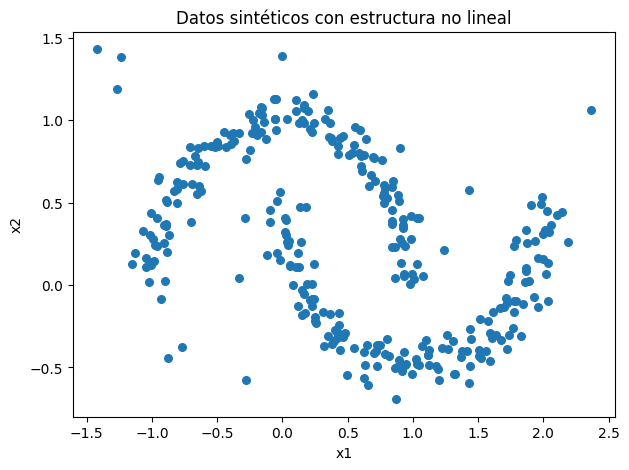

In [4]:
from sklearn.datasets import make_moons

np.random.seed(42)
X, y_true = make_moons(n_samples=300, noise=0.07, random_state=42)

ruido_extra = np.random.uniform(low=[-1.5, -0.8], high=[2.5, 1.5], size=(20, 2))
X = np.vstack([X, ruido_extra])

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title('Datos sintéticos con estructura no lineal')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### 🎯 **Comparación visual con K-Means**

Antes de aplicar DBSCAN, observemos cómo responde K-Means sobre este mismo conjunto de datos. Esto permite visualizar con claridad la diferencia entre un método basado en centroides y otro basado en densidad.

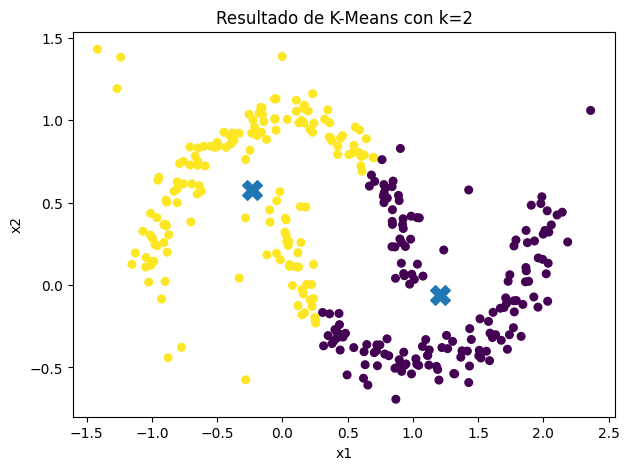

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200)
plt.title('Resultado de K-Means con k=2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

##### 📝 **Lectura del resultado**

K-Means logra dividir el espacio en dos regiones, pero no respeta adecuadamente la forma de las dos lunas. Esto ocurre porque el algoritmo busca minimizar la variación interna alrededor de centroides, lo cual favorece particiones de tipo convexo. En datos con geometría curva o conectividad irregular, esta suposición puede ser inadecuada.

### 🤖 **Implementación de DBSCAN usando scikit-learn**

Ahora aplicaremos DBSCAN con la implementación estándar de `scikit-learn`. Esta versión ya resuelve internamente la búsqueda de vecindades y la expansión de clusters.

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.22, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

labels_dbscan[:20]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

##### 📊 **Visualización del resultado**

En `DBSCAN`, los puntos etiquetados con `-1` representan ruido. El resto de enteros corresponde a clusters encontrados automáticamente.

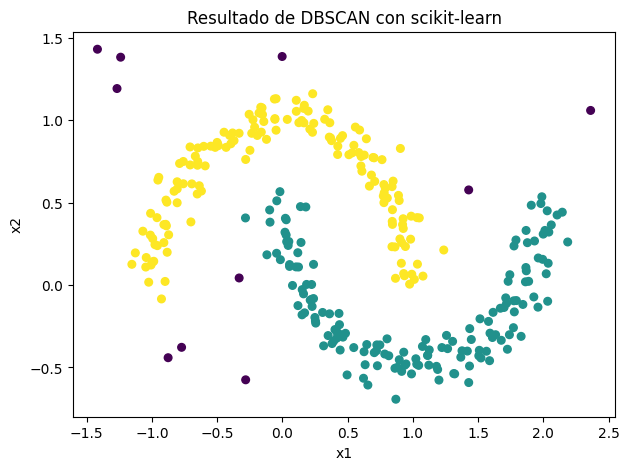

In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, s=30)
plt.title('Resultado de DBSCAN con scikit-learn')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

##### 🧾 **Número de clusters y ruido detectado**

Una forma práctica de resumir la salida es contar cuántos grupos distintos se detectaron y cuántos puntos quedaron como ruido.

In [8]:
clusters_encontrados = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
puntos_ruido = np.sum(labels_dbscan == -1)

print('Número de clusters encontrados:', clusters_encontrados)
print('Número de puntos marcados como ruido:', puntos_ruido)

Número de clusters encontrados: 2
Número de puntos marcados como ruido: 10


##### 🧪 **Exploración de parámetros**

Para entender la sensibilidad de DBSCAN, resulta útil experimentar con distintos valores de `eps`. La siguiente celda compara varios escenarios.

In [9]:
eps_values = [0.12, 0.18, 0.22, 0.30]

for eps in eps_values:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f'eps={eps:.2f} -> clusters={n_clusters}, ruido={n_noise}')

eps=0.12 -> clusters=3, ruido=31
eps=0.18 -> clusters=2, ruido=12
eps=0.22 -> clusters=2, ruido=10
eps=0.30 -> clusters=2, ruido=8


### 🛠️ **Implementación de DBSCAN sin usar la librería**

Para comprender realmente DBSCAN, implementaremos una versión desde cero usando únicamente NumPy. La meta no es optimizar al máximo el código, sino hacer explícita la lógica del algoritmo: búsqueda de vecinos, identificación de puntos núcleo y expansión de clusters.

##### 🧱 **Función para encontrar vecinos**

Dado un índice `i`, esta función identifica todos los puntos cuya distancia euclidiana al punto `i` es menor o igual que `eps`.

In [10]:
def region_query(X, point_idx, eps):
    distancias = np.sqrt(np.sum((X - X[point_idx])**2, axis=1))
    vecinos = np.where(distancias <= eps)[0]
    return vecinos

##### 🔄 **Expansión de clusters**

Una vez se detecta un punto núcleo, expandimos el cluster recorriendo su vecindad. Si algún vecino también es núcleo, sus vecinos se agregan a la exploración.

In [11]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples, visited):
    labels[point_idx] = cluster_id
    i = 0
    neighbors = list(neighbors)

    while i < len(neighbors):
        neighbor_idx = neighbors[i]

        if not visited[neighbor_idx]:
            visited[neighbor_idx] = True
            neighbor_neighbors = region_query(X, neighbor_idx, eps)

            if len(neighbor_neighbors) >= min_samples:
                for n in neighbor_neighbors:
                    if n not in neighbors:
                        neighbors.append(n)

        if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id

        i += 1

##### 🧠 **Implementación completa de DBSCAN**

La siguiente función recorre todos los puntos y aplica la lógica general del algoritmo.

In [12]:
def dbscan_manual(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -1)
    visited = np.zeros(n, dtype=bool)
    cluster_id = 0

    for point_idx in range(n):
        if visited[point_idx]:
            continue

        visited[point_idx] = True
        neighbors = region_query(X, point_idx, eps)

        if len(neighbors) < min_samples:
            labels[point_idx] = -1
        else:
            expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples, visited)
            cluster_id += 1

    return labels

##### ▶️ **Ejecución de la versión manual**

Aplicamos ahora la implementación desde cero al mismo conjunto de datos.

In [13]:
labels_manual = dbscan_manual(X, eps=0.22, min_samples=5)
labels_manual[:20]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

##### 📉 **Visualización de la implementación manual**

Si la implementación es correcta, deberíamos obtener una estructura de clusters muy cercana a la de `scikit-learn`.

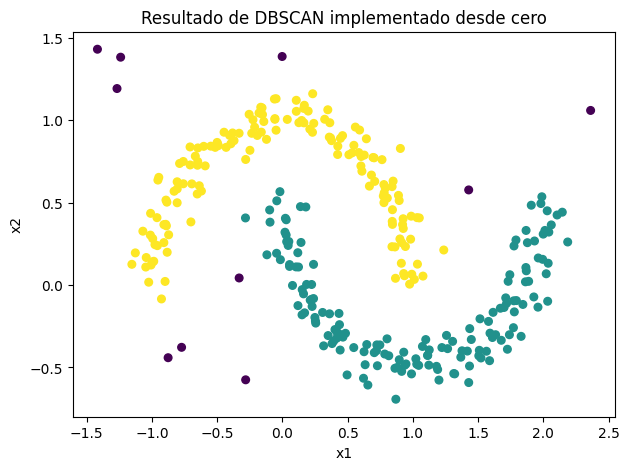

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_manual, s=30)
plt.title('Resultado de DBSCAN implementado desde cero')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

##### 🔬 **Comparación entre ambas implementaciones**

Como las etiquetas de clusters pueden cambiar de nombre entre implementaciones, no siempre tiene sentido comparar los enteros directamente. Sin embargo, sí podemos comparar cantidades globales como el número de clusters y de puntos de ruido.

In [15]:
clusters_manual = len(set(labels_manual)) - (1 if -1 in labels_manual else 0)
ruido_manual = np.sum(labels_manual == -1)

clusters_sklearn = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
ruido_sklearn = np.sum(labels_dbscan == -1)

print('scikit-learn -> clusters:', clusters_sklearn, ', ruido:', ruido_sklearn)
print('manual       -> clusters:', clusters_manual, ', ruido:', ruido_manual)

scikit-learn -> clusters: 2 , ruido: 10
manual       -> clusters: 2 , ruido: 10


### 📐 **Discusión metodológica**

Implementar DBSCAN manualmente ayuda a ver con claridad varios aspectos que en la práctica suelen quedar ocultos detrás de una librería. Primero, el algoritmo depende fuertemente de la noción de distancia. Segundo, la búsqueda de vecinos puede ser costosa si el número de puntos crece mucho. Tercero, el concepto de conectividad por densidad explica por qué DBSCAN puede detectar formas curvas o arbitrarias donde K-Means falla.

##### 🧭 **¿Cuándo conviene usar DBSCAN?**

DBSCAN es una buena elección cuando:
- no se conoce el número de clusters,
- se sospecha la presencia de ruido u outliers,
- los grupos pueden tener formas no convexas,
- se quiere una interpretación basada en densidad y conectividad.

##### 🚫 **¿Cuándo puede no ser la mejor opción?**

Puede no ser ideal cuando:
- hay clusters con densidades muy distintas,
- la dimensión es muy alta y las distancias se vuelven menos informativas,
- es difícil seleccionar un único `eps` adecuado para todo el espacio.

### 🏁 **Cierre de la sesión**

En este notebook estudiamos DBSCAN como un algoritmo de clustering basado en densidad. Vimos que su fortaleza principal frente a K-Means es la capacidad de detectar clusters con formas arbitrarias y de separar ruido. Además, implementamos el algoritmo de dos maneras: usando `scikit-learn` para una solución práctica y construyéndolo desde cero para entender su lógica interna. Con esto queda una base sólida para conectar clustering, detección de outliers y análisis no supervisado en módulos posteriores.